Laboratory 5 instruction part 2 - MLflow

1. MLflow Tracking server configuration

In [1]:
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


2. Automatic logging with scikit-learn

2.1 Dataset preparation

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [3]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [4]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [5]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


2.2 Training with MLflow autologging

In [6]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog-2")

2026/04/23 23:21:51 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/04/23 23:21:55 INFO mlflow.tracking.fluent: Experiment with name 'ames-housing-autolog-2' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/eryk/Repo/MLOps_AGH_Lab05/mlflow-artifacts/3', creation_time=1776979314993, experiment_id='3', last_update_time=1776979314993, lifecycle_stage='active', name='ames-housing-autolog-2', tags={}>

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [8]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [9]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/23 23:21:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:55 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:56 WARNING mlflow.sklearn: Failed t


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/3/runs/e8b80245211a49febbd44e0f010fe940
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:21:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/3/runs/54510022a73d4a1f9af3f87aecdba3de
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:21:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:21:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/3/runs/16525b1aac7d48919aaf24d85acd54f2
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:03 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:06 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:09 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:12 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:19 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/3/runs/8b74cecfcd884539bbaf8465e0cb94de
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:21 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:22 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:23 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:24 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:26 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/3/runs/1af509b5f80743148d966d1b53764991
🧪 View experiment at: http://localhost:5001/#/experiments/3


1. What columns can be selected

Attributes
Dataset
User
Source
Version
Models
Description 
Metrics (10)
cv_r2_mean
cv_r2_std
mean_absolute_error_X_test
r2_score_X_test
root_mean_squared_error_X_test
training_mean_absolute_error
training_mean_squared_error
training_r2_score
training_root_mean_squared_error
training_score 
Parameters (39)
algorithm
alpha
bootstrap
ccp_alpha
copy_X
criterion
fit_intercept
init
leaf_size
learning_rate
loss
max_depth
max_features
max_iter
max_leaf_nodes
max_samples
metric
metric_params
min_impurity_decrease
min_samples_leaf
min_samples_split
min_weight_fraction_leaf
monotonic_cst
n_estimators
n_iter_no_change
n_jobs
n_neighbors
oob_score
p
positive
random_state
solver
splitter
subsample
tol
validation_fraction
verbose
warm_start
weights 
Tags (2)
estimator_name
estimator_class

2. Pick a particular run and check what values are logged automatically

training_mean_squared_error
training_mean_absolute_error
training_r2_score
training_root_mean_squared_error
training_score
root_mean_squared_error_X_test
mean_absolute_error_X_test
r2_score_X_test
cv_r2_mean
cv_r2_std

3. Select columns to compare a given metric between runs, e.g. MAE

4. Sort algorithms by the selected metric to pick the best one

According to mean_absolute_error_X_test
    Gradient Boosting
    Random Forest
    Ridge Regression
    Decision Tree
    K-Nearest Neighbors


2.3 Connecting DVC and MLflow

In [10]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: f44053333f88a0646819936b37f000ee
File size: 162560 bytes
Data path: ames_data_2006_2008.parquet


Exercise 1 - Logging DVC metadata in MLflow

1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any supervised learning methods from scikit-learn. Find some other models or parameters to tune our current models with and run the experiments again.
2. Use the function fit_sklearn_models_with_cv() created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined get_dvc_metadata function with the .dvc metadata file. Then you can just for each experiment add param logging like:
```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [11]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Linear Regression", LinearRegression()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=6, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=4)),
    ("Lasso", Lasso(alpha=75)),
    ("SVR", SVR(kernel='rbf')),
]

In [12]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [13]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/23 23:22:27 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:27 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:29 WARNING mlflow.sklearn: Failed t


Linear Regression:
  RMSE: 24060.43
  MAE: 16741.64
  R^2: 0.899
  CV R^2 (mean ± std): 0.867 ± 0.074
🏃 View run Linear Regression at: http://localhost:5001/#/experiments/3/runs/c35a7005dbb94260a473332fc8e3859b
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 35131.14
  MAE: 23610.92
  R^2: 0.784
  CV R^2 (mean ± std): 0.777 ± 0.078
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/3/runs/e63620889b6040378f4504d96927c59c
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 39656.62
  MAE: 26989.18
  R^2: 0.725
  CV R^2 (mean ± std): 0.690 ± 0.062
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/3/runs/6fe64ac5b6a64526b234ccbdec118811
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:32 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:32 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:32 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:32 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Lasso:
  RMSE: 22805.26
  MAE: 15767.19
  R^2: 0.909
  CV R^2 (mean ± std): 0.899 ± 0.031
🏃 View run Lasso at: http://localhost:5001/#/experiments/3/runs/d834cf0c17e0495f951b1104acb2ebf8
🧪 View experiment at: http://localhost:5001/#/experiments/3


2026/04/23 23:22:34 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:34 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:36 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/23 23:22:37 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



SVR:
  RMSE: 77482.01
  MAE: 54914.40
  R^2: -0.051
  CV R^2 (mean ± std): -0.103 ± 0.070
🏃 View run SVR at: http://localhost:5001/#/experiments/3/runs/9d8cacc998e24e9e920a188d51cc9883
🧪 View experiment at: http://localhost:5001/#/experiments/3


3. Manual logging with PyTorch

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual-2")

2026/04/23 23:22:38 INFO mlflow.tracking.fluent: Experiment with name 'pytorch-housing-manual-2' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/eryk/Repo/MLOps_AGH_Lab05/mlflow-artifacts/4', creation_time=1776979358337, experiment_id='4', last_update_time=1776979358337, lifecycle_stage='active', name='pytorch-housing-manual-2', tags={}>

3.1 Targets transformation

<Axes: ylabel='Frequency'>

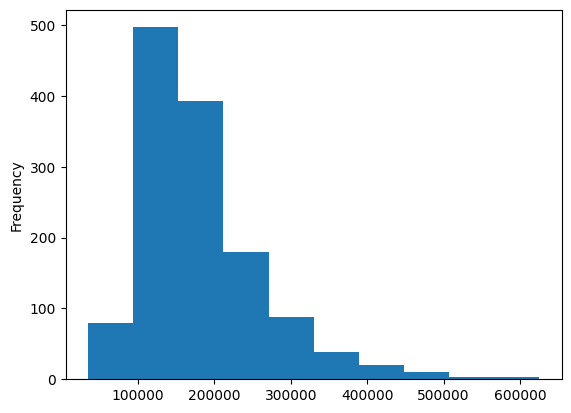

In [15]:
y_train.plot.hist()

<Axes: ylabel='Frequency'>

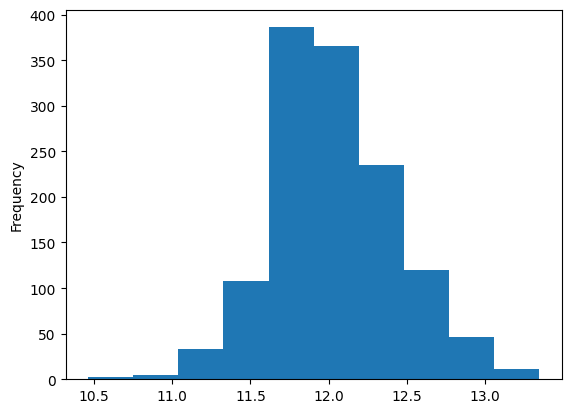

In [16]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

3.2 Define and train the model

In [17]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [18]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

In [19]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [20]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29030.59, MAE: 21825.14 R^2: 0.883

Training Fold 2/5...
  Fold 2 Validation - RMSE: 76773.51, MAE: 59437.33 R^2: 0.034

Training Fold 3/5...
  Fold 3 Validation - RMSE: 45338.60, MAE: 35289.50 R^2: 0.694

Training Fold 4/5...
  Fold 4 Validation - RMSE: 34842.19, MAE: 22891.22 R^2: 0.788

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50990.05, MAE: 41154.86 R^2: 0.552

Cross-validation complete. Mean R^2: 0.590 (+/- 0.299)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.590 (+/- 0.299)

Cross-Validation Performance:
  R^2: 0.889
  RMSE: 25141.88
  MAE: 18535.35
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/4/runs/0edc3f2e2a394c98920b1c1a1a34d116
🧪 View experiment at: http://localhost:5001/#/experiments/4

{'rmse': 25141.875,
 'mae': 18535.353515625,
 'r2': 0.8893685340881348,
 'cv_r2_mean': np.float64(0.590156614780426),
 'cv_r2_std': np.float64(0.29880437265642007),
 'cv_scores': [0.8832190036773682,
  0.033900439739227295,
  0.6937592029571533,
  0.7875226140022278,
  0.5523818135261536]}

Exercise 2

1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

In [21]:
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],
    "num_samples": X_train.shape[0],  
    "target_normalized": True,      
    "k_folds": 5,                  
}

In [22]:
# Define multiple experiments to run
configs = [
    {
        "name": "units_256",
        "hidden_units": 256,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "units_64",
        "hidden_units": 64,        
        "dropout": 0.1,
        "learning_rate": 0.03,   
        "epochs": 150,
        "batch_size": 32,    
    },
    {
    "name": "dropout_05",
    "hidden_units": 128,
    "dropout": 0.5,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
    },
    {
    "name": "dropout_001",
    "hidden_units": 128,
    "dropout": 0.01,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
    },
    {
    "name": "learning_009",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.09,
    "epochs": 150,
    "batch_size": 32,
    },
    {
    "name": "learning_0001",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.001,
    "epochs": 150,
    "batch_size": 32,
    },
    {
    "name": "epochs_250",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 250,
    "batch_size": 32,
    },
    {
    "name": "batch_16",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 16,
    },
    {
    "name": "units_64_batch_16_dropout_03",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 16,
    },
    {
    "name": "dropout_02_learning_001_epochs_200",
    "hidden_units": 128,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 200,
    "batch_size": 64,
    }
]

In [23]:
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for units_256...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 35922.88, MAE: 26571.21 R^2: 0.821

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31802.74, MAE: 21652.78 R^2: 0.834

Training Fold 3/5...
  Fold 3 Validation - RMSE: 45666.51, MAE: 36378.91 R^2: 0.689

Training Fold 4/5...
  Fold 4 Validation - RMSE: 111691.10, MAE: 86977.52 R^2: -1.183

Training Fold 5/5...
  Fold 5 Validation - RMSE: 56372.09, MAE: 40891.14 R^2: 0.453

Cross-validation complete. Mean R^2: 0.323 (+/- 0.765)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.323 (+/- 0.765)

Cross-Validation Performance:
  R^2: 0.499
  RMSE: 53476.69
  MAE: 43975.05
Test Set Performance:
FINAL RESULTS for units_256:

🏃 View run units_256 at: http://localhost:5001/#/experiments/4/runs/48f9057d20d944a8906945958a997398
🧪 View experiment at: http://localhost:5001/#/experiments

What changes impacted the model performance the most?
The biggest impact have hidden_units parameter. The best result archieved configuration with 64 units - less than experiment base config. This resulted in both faster training and better results.

What changes disrupted the training process?
In the case of negative impact, the lower the learning_rate parameter, the worse the result. Also more hidden_units resulted one of the worse result.

Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.
Overfitting is visible in first PyTorch experiment.
CV R^2 std = 0,299. It means that model is very unstable. Also the difference between CV R^2 and test_R^2 (0,89 vs 0,59) is sign of overfitting. 
For comparision, a decrease hidden_units resulted in almost 15x lower CV R^2 (and better other metrics), which means that the model was trained more effectively. 
